# Data Cleaning and Preparation

## Libraries and dataset import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import warnings
warnings.filterwarnings('ignore', category = DeprecationWarning)
warnings.filterwarnings('ignore', category = FutureWarning)

In [2]:
dataset_url = 'https://drive.google.com/file/d/1LkH5hy3pleZ4a0cyEvUZ9eSnxTC_sosH/view?usp=sharing'
dataset_get = 'https://drive.google.com/uc?id=' + dataset_url.split('/')[-2]
dataset = pd.read_csv(dataset_get)
dataset

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend
...,...,...,...,...,...
20502,9682,Coffee,4/9/2017 14:32,afternoon,weekend
20503,9682,Tea,4/9/2017 14:32,afternoon,weekend
20504,9683,Coffee,4/9/2017 14:57,afternoon,weekend
20505,9683,Pastry,4/9/2017 14:57,afternoon,weekend


Making a copy of the dataset for further analysis and standardizing the column names (all lowercase).

In [3]:
df = dataset.copy()
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


## Data type conversion

Converting data types:
* `transaction` and `item` to string
* `period_day` and `weekday_weekend` to category
* `date_time` to datetime

In [4]:
df['transaction'] = df['transaction'].astype('string')
df['item'] = df['item'].astype('string')

df['period_day'] = df['period_day'].astype('category')
df['weekday_weekend'] = df['weekday_weekend'].astype('category')

df['date_time'] = pd.to_datetime(df['date_time'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction      20507 non-null  string        
 1   item             20507 non-null  string        
 2   date_time        20507 non-null  datetime64[ns]
 3   period_day       20507 non-null  category      
 4   weekday_weekend  20507 non-null  category      
dtypes: category(2), datetime64[ns](1), string(2)
memory usage: 521.1 KB


## Typo check and standardization

Checking for typos on `period_day` and `weekday_weekend` columns.

In [5]:
df['period_day'].unique().to_list()

['morning', 'afternoon', 'evening', 'night']

In [6]:
df['weekday_weekend'].unique().to_list()

['weekend', 'weekday']

No typos found on those columns.

Standardizing the values of `item` column into lowercases and trimming whitespaces.

In [7]:
df['item'] = df['item'].str.lower().str.strip()

In [8]:
df.head()

,transaction,item,date_time,period_day,weekday_weekend
0,1,bread,2016-10-30 09:58:00,morning,weekend
1,2,scandinavian,2016-10-30 10:05:00,morning,weekend
2,2,scandinavian,2016-10-30 10:05:00,morning,weekend
3,3,hot chocolate,2016-10-30 10:07:00,morning,weekend
4,3,jam,2016-10-30 10:07:00,morning,weekend


## Handling missing values and duplicates

Checking for missing values.

In [9]:
df.isna().sum()

,0
transaction,0
item,0
date_time,0
period_day,0
weekday_weekend,0


No missing values were found.

Dropping duplicates within the same transaction. Duplicate item records within the same transaction were removed to avoid overstating product associations in market basket analysis.

In [10]:
df = df.drop_duplicates(subset = ['transaction', 'item'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18887 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction      18887 non-null  string        
 1   item             18887 non-null  string        
 2   date_time        18887 non-null  datetime64[ns]
 3   period_day       18887 non-null  category      
 4   weekday_weekend  18887 non-null  category      
dtypes: category(2), datetime64[ns](1), string(2)
memory usage: 627.4 KB


# Exploratory Data Analysis

## Overall EDA

Creating transaction-level basket size.

In [11]:
basket_size = (
    df.groupby('transaction')
    .agg(
        items_per_transaction=('item', 'nunique'),
        day_type=('weekday_weekend', 'first')
    )
    .reset_index()
)

basket_size.head()

,transaction,items_per_transaction,day_type
0,1,1,weekend
1,10,2,weekend
2,100,1,weekday
3,1000,2,weekday
4,1001,2,weekday


Calculating the average basket size & single-item rate

In [12]:
avg_items = basket_size['items_per_transaction'].mean()

single_item_rate = (basket_size['items_per_transaction'] == 1).mean()

print(f"Average items per transaction: {avg_items:.2f}")
print(f"Single-item transaction rate: {single_item_rate:.1%}")

Average items per transaction: 2.00
Single-item transaction rate: 41.7%


## EDA grouped by day type

Calculating transaction count and average basket size by day type (weekdays vs. weekends).

In [13]:
trx_by_day = (
    basket_size['day_type']
    .value_counts()
    .reset_index(name = 'transaction_count')
    .rename(columns = {'index': 'day_type'})
)

trx_by_day

,day_type,transaction_count
0,weekday,6145
1,weekend,3320


In [14]:
avg_items_by_day = (
    basket_size
    .groupby('day_type')['items_per_transaction']
    .mean()
    .reset_index()
)

avg_items_by_day

,day_type,items_per_transaction
0,weekday,1.925142
1,weekend,2.125602


Weekday has larger volume but fewer items per transaction, suggesting routine single-item purchasing behavior. In contrast, weekend transactions are fewer but has higher average basket sizes, indicating more exploratory or bundled purchases. This pattern motivates a contextual examination of association rules by day type.

## Transaction count by items

Identifying anchor products.

In [15]:
total_transactions = basket_size.shape[0]

item_trx_count = (
    df.groupby('item')['transaction']
    .nunique()
    .reset_index(name = 'transaction_count')
    .sort_values('transaction_count', ascending = False)
)

item_trx_count['transaction_share'] = (
    item_trx_count['transaction_count'] / total_transactions
)

item_trx_count.head()

,item,transaction_count,transaction_share
23,coffee,4528,0.478394
11,bread,3097,0.327205
83,tea,1350,0.142631
15,cake,983,0.103856
65,pastry,815,0.086107


## EDA visualizations

Creating charts for basket size distribution, top 10 products, and single-item vs. multi-item transactions.

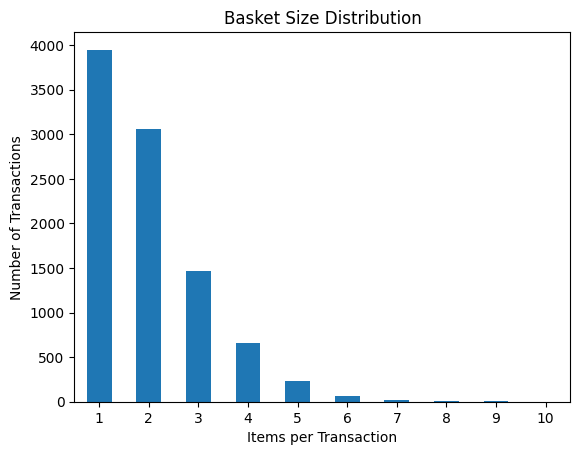

In [16]:
basket_dist = (
    basket_size['items_per_transaction']
    .value_counts()
    .sort_index()
)

plt.figure()
basket_dist.plot(kind = 'bar')
plt.xticks(rotation = 0)
plt.xlabel('Items per Transaction')
plt.ylabel('Number of Transactions')
plt.title('Basket Size Distribution')
plt.show()

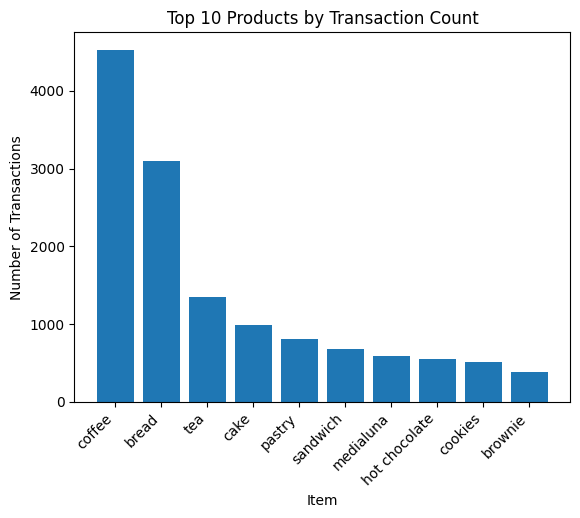

In [17]:
top_items = item_trx_count.head(10)

plt.figure()
plt.bar(top_items['item'], top_items['transaction_count'])
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('Item')
plt.ylabel('Number of Transactions')
plt.title('Top 10 Products by Transaction Count')
plt.show()

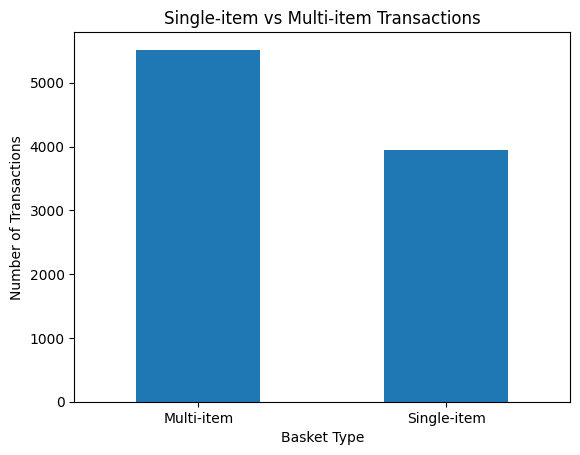

In [18]:
basket_size['basket_type'] = basket_size['items_per_transaction'].apply(
    lambda x: 'Single-item' if x == 1 else 'Multi-item'
)

basket_type_dist = basket_size['basket_type'].value_counts()

plt.figure()
basket_type_dist.plot(kind = 'bar')
plt.xlabel('Basket Type')
plt.ylabel('Number of Transactions')
plt.title('Single-item vs Multi-item Transactions')
plt.xticks(rotation=0)
plt.show()

# Market Basket Analysis

## MBA preparation

Creating transaction-level baskets.

In [19]:
basket = (
    df.groupby('transaction')['item']
    .apply(list)
    .reset_index(name = 'items')
)

basket.head()

,transaction,items
0,1,[bread]
1,10,"[scandinavian, medialuna]"
2,100,[bread]
3,1000,"[scandinavian, chimichurri oil]"
4,1001,"[bread, truffles]"


Converting the basket table into a binary matrix, where:
* rows = transactions
* columns = items
* 1 = item present, 0 = item absent

In [20]:
transactions = basket['items'].tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket_encoded = pd.DataFrame(
    te_array,
    columns = te.columns_
)

basket_encoded.head()

,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,...,the bart,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


## Apriori algorithm

Running apriori with a minimum support of 1%.

In [21]:
frequent_itemsets = apriori(
    basket_encoded,
    min_support = 0.01,
    use_colnames = True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by = 'support',
    ascending = False
)

frequent_itemsets.head()

,support,itemsets
6,0.478394,(coffee)
2,0.327205,(bread)
26,0.142631,(tea)
4,0.103856,(cake)
34,0.090016,"(bread, coffee)"


In [22]:
frequent_itemsets['itemsets'].apply(len).value_counts()

,count
itemsets,
1,30
2,28
3,3


## Association rules

Generating association rules with a minimum threshold of 0.1.

In [23]:
rules = association_rules(
    frequent_itemsets,
    metric = 'confidence',
    min_threshold = 0.1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(bread),(coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
1,(coffee),(bread),0.478394,0.327205,0.090016,0.188163,0.575059,1.0,-0.066517,0.828731,-0.586210,0.125794,-0.206665,0.231634
2,(cake),(coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
3,(coffee),(cake),0.478394,0.103856,0.054728,0.114399,1.101515,1.0,0.005044,1.011905,0.176684,0.103745,0.011765,0.320679
4,(tea),(coffee),0.142631,0.478394,0.049868,0.349630,0.730840,1.0,-0.018366,0.802014,-0.300482,0.087310,-0.246862,0.226935


Filtering the rules, focusing on:
* lift > 1.0
* confidence >= 0.2
* single-item consequents

In [24]:
filtered_rules = rules[
    (rules['lift'] > 1.0) &
    (rules['confidence'] >= 0.2) &
    (rules['consequents'].apply(lambda x: len(x) == 1))
].copy()

filtered_rules = filtered_rules.sort_values(
    by = 'lift',
    ascending = False
)

filtered_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
43,"(tea, coffee)",(cake),0.049868,0.103856,0.010037,0.201271,1.937977,1.0,0.004858,1.121962,0.509401,0.069853,0.108705,0.148957
13,(cake),(tea),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,0.420538,0.106736,0.100611,0.197779
15,(toast),(coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
26,(sandwich),(tea),0.071844,0.142631,0.014369,0.200000,1.402222,1.0,0.004122,1.071712,0.309050,0.071806,0.066913,0.150370
35,(spanish brunch),(coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
8,(medialuna),(coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
6,(pastry),(coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
19,(alfajores),(coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
17,(juice),(coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
7,(sandwich),(coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150


## Coffee rule analysis

This step looks at rules where coffee appears as the antecedent to check whether buying coffee alone tends to lead to specific add-on items. The goal is to understand if coffee actively drives additional purchases, or if it mainly shows up as a frequent item within larger baskets.

In [25]:
coffee_rules = filtered_rules[
    filtered_rules['antecedents'].apply(lambda x: 'coffee' in x)
]

coffee_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
43,"(tea, coffee)",(cake),0.010037,0.201271,1.937977


Only one rule with coffee as the sole antecedent meets the confidence and lift thresholds. This indicates that coffee alone does not strongly predict specific add-on items. A high-lift rule involving coffee in a multi-item antecedent highlights **bundle-style behavior**.

## Ranking add-on rules

The top add-on rules were selected by ranking rules using a composite score based on lift and confidence. This approach prioritizes item combinations that are both meaningfully associated and likely to result in successful add-on purchases, ensuring the selected rules are practical for cross-selling use cases.

In [26]:
filtered_rules['rule_score'] = (
    filtered_rules['lift'] * filtered_rules['confidence']
)

ranked_rules = filtered_rules.sort_values(
    by = 'rule_score',
    ascending = False
)

ranked_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'rule_score']]

,antecedents,consequents,support,confidence,lift,rule_score
15,(toast),(coffee),0.023666,0.704403,1.472431,1.037184
35,(spanish brunch),(coffee),0.010882,0.598837,1.251766,0.749604
8,(medialuna),(coffee),0.035182,0.569231,1.189878,0.677315
6,(pastry),(coffee),0.047544,0.552147,1.154168,0.637271
19,(alfajores),(coffee),0.019651,0.540698,1.130235,0.611115
17,(juice),(coffee),0.020602,0.534247,1.116750,0.596620
7,(sandwich),(coffee),0.038246,0.532353,1.112792,0.592398
2,(cake),(coffee),0.054728,0.526958,1.101515,0.580452
21,(scone),(coffee),0.018067,0.522936,1.093107,0.571625
11,(cookies),(coffee),0.028209,0.518447,1.083723,0.561852


The rules **toast → coffee**, **spanish brunch → coffee**, and **medialuna → coffee** were selected because they consistently rank highest among add-on rules when considering both confidence and lift. These items represent common food purchases where coffee is frequently added, making them strong and practical candidates for cross-selling. Together, they highlight situations where prompting coffee at the point of sale is most likely to succeed and meaningfully increase basket value.

## Contextual MBA (day type)

Attaching day type to `basket_encoded`.

In [27]:
basket_encoded_with_day = basket_encoded.copy()
basket_encoded_with_day['day_type'] = basket_size['day_type'].values

basket_encoded_with_day.head()

,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,...,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge,day_type
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,weekend
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,weekend
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,weekday
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,weekday
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,weekday


Splitting the data above by day type.

In [28]:
weekday_data = basket_encoded_with_day[
    basket_encoded_with_day['day_type'] == 'weekday'
]

weekend_data = basket_encoded_with_day[
    basket_encoded_with_day['day_type'] == 'weekend'
]

Creating a function to help compute confidence.

In [29]:
def compute_confidence(data, antecedent_items, consequent_item):
    antecedent_mask = data[list(antecedent_items)].all(axis = 1)
    both_mask = antecedent_mask & data[consequent_item]

    if antecedent_mask.sum() == 0:
        return 0
    return both_mask.sum() / antecedent_mask.sum()


Defining the rules to test, which are **toast → coffee**, **spanish brunch → coffee**, and **medialuna → coffee**.

In [30]:
rules_to_test = {
    'toast → coffee': (['toast'], 'coffee'),
    'spanish brunch → coffee': (['spanish brunch'], 'coffee'),
    'medialuna → coffee': (['medialuna'], 'coffee'),
    '(tea, coffee) → cake': (['tea', 'coffee'], 'cake')
}

Computing contextual confidence.

In [31]:
contextual_results = []

for rule_name, (antecedents, consequent) in rules_to_test.items():
    weekday_conf = compute_confidence(
        weekday_data, antecedents, consequent
    )
    weekend_conf = compute_confidence(
        weekend_data, antecedents, consequent
    )

    contextual_results.append({
        'rule': rule_name,
        'weekday_confidence': weekday_conf,
        'weekend_confidence': weekend_conf
    })

contextual_conf_df = pd.DataFrame(contextual_results)
contextual_conf_df

,rule,weekday_confidence,weekend_confidence
0,toast → coffee,0.711790,0.685393
1,spanish brunch → coffee,0.450704,0.702970
2,medialuna → coffee,0.543210,0.601533
3,"(tea, coffee) → cake",0.188552,0.222857


The contextual confidence analysis shows that purchase behavior differs by day type. Routine add-ons such as toast → coffee perform more strongly on weekdays, while more indulgent add-ons and bundle behavior, such as (tea, coffee) → cake, strengthen on weekends. This confirms that add-on and bundle dynamics reflect different purchase contexts rather than uniform behavior. These findings validate the importance of context when interpreting market basket patterns and provide a clear foundation for subsequent visualization and recommendation development.

Preparing curated rule table for Tableau.

In [32]:
rules_export = filtered_rules.copy()

rules_export['antecedent'] = rules_export['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)

rules_export['consequent'] = rules_export['consequents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)

rules_export = rules_export[
    ['antecedent', 'consequent', 'confidence', 'lift']
]

rules_export = rules_export.sort_values(
    by='confidence',
    ascending=False
)

rules_export.to_csv(
    'mba_rules_curated.csv',
    index=False
)

rules_export.head(10)

,antecedent,consequent,confidence,lift
15,toast,coffee,0.704403,1.472431
35,spanish brunch,coffee,0.598837,1.251766
8,medialuna,coffee,0.569231,1.189878
6,pastry,coffee,0.552147,1.154168
19,alfajores,coffee,0.540698,1.130235
17,juice,coffee,0.534247,1.116750
7,sandwich,coffee,0.532353,1.112792
2,cake,coffee,0.526958,1.101515
21,scone,coffee,0.522936,1.093107
11,cookies,coffee,0.518447,1.083723
